---
title: "Lab 1: Gapminder Data Visualization"
format:
  html:
    theme: cosmo
    toc: true
    embed-resources: true
execute: 
    echo: true
---

c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 12 x 7 in image.
c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: plot1_bubble_chart.png
c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 1 rows containing missing values.
c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


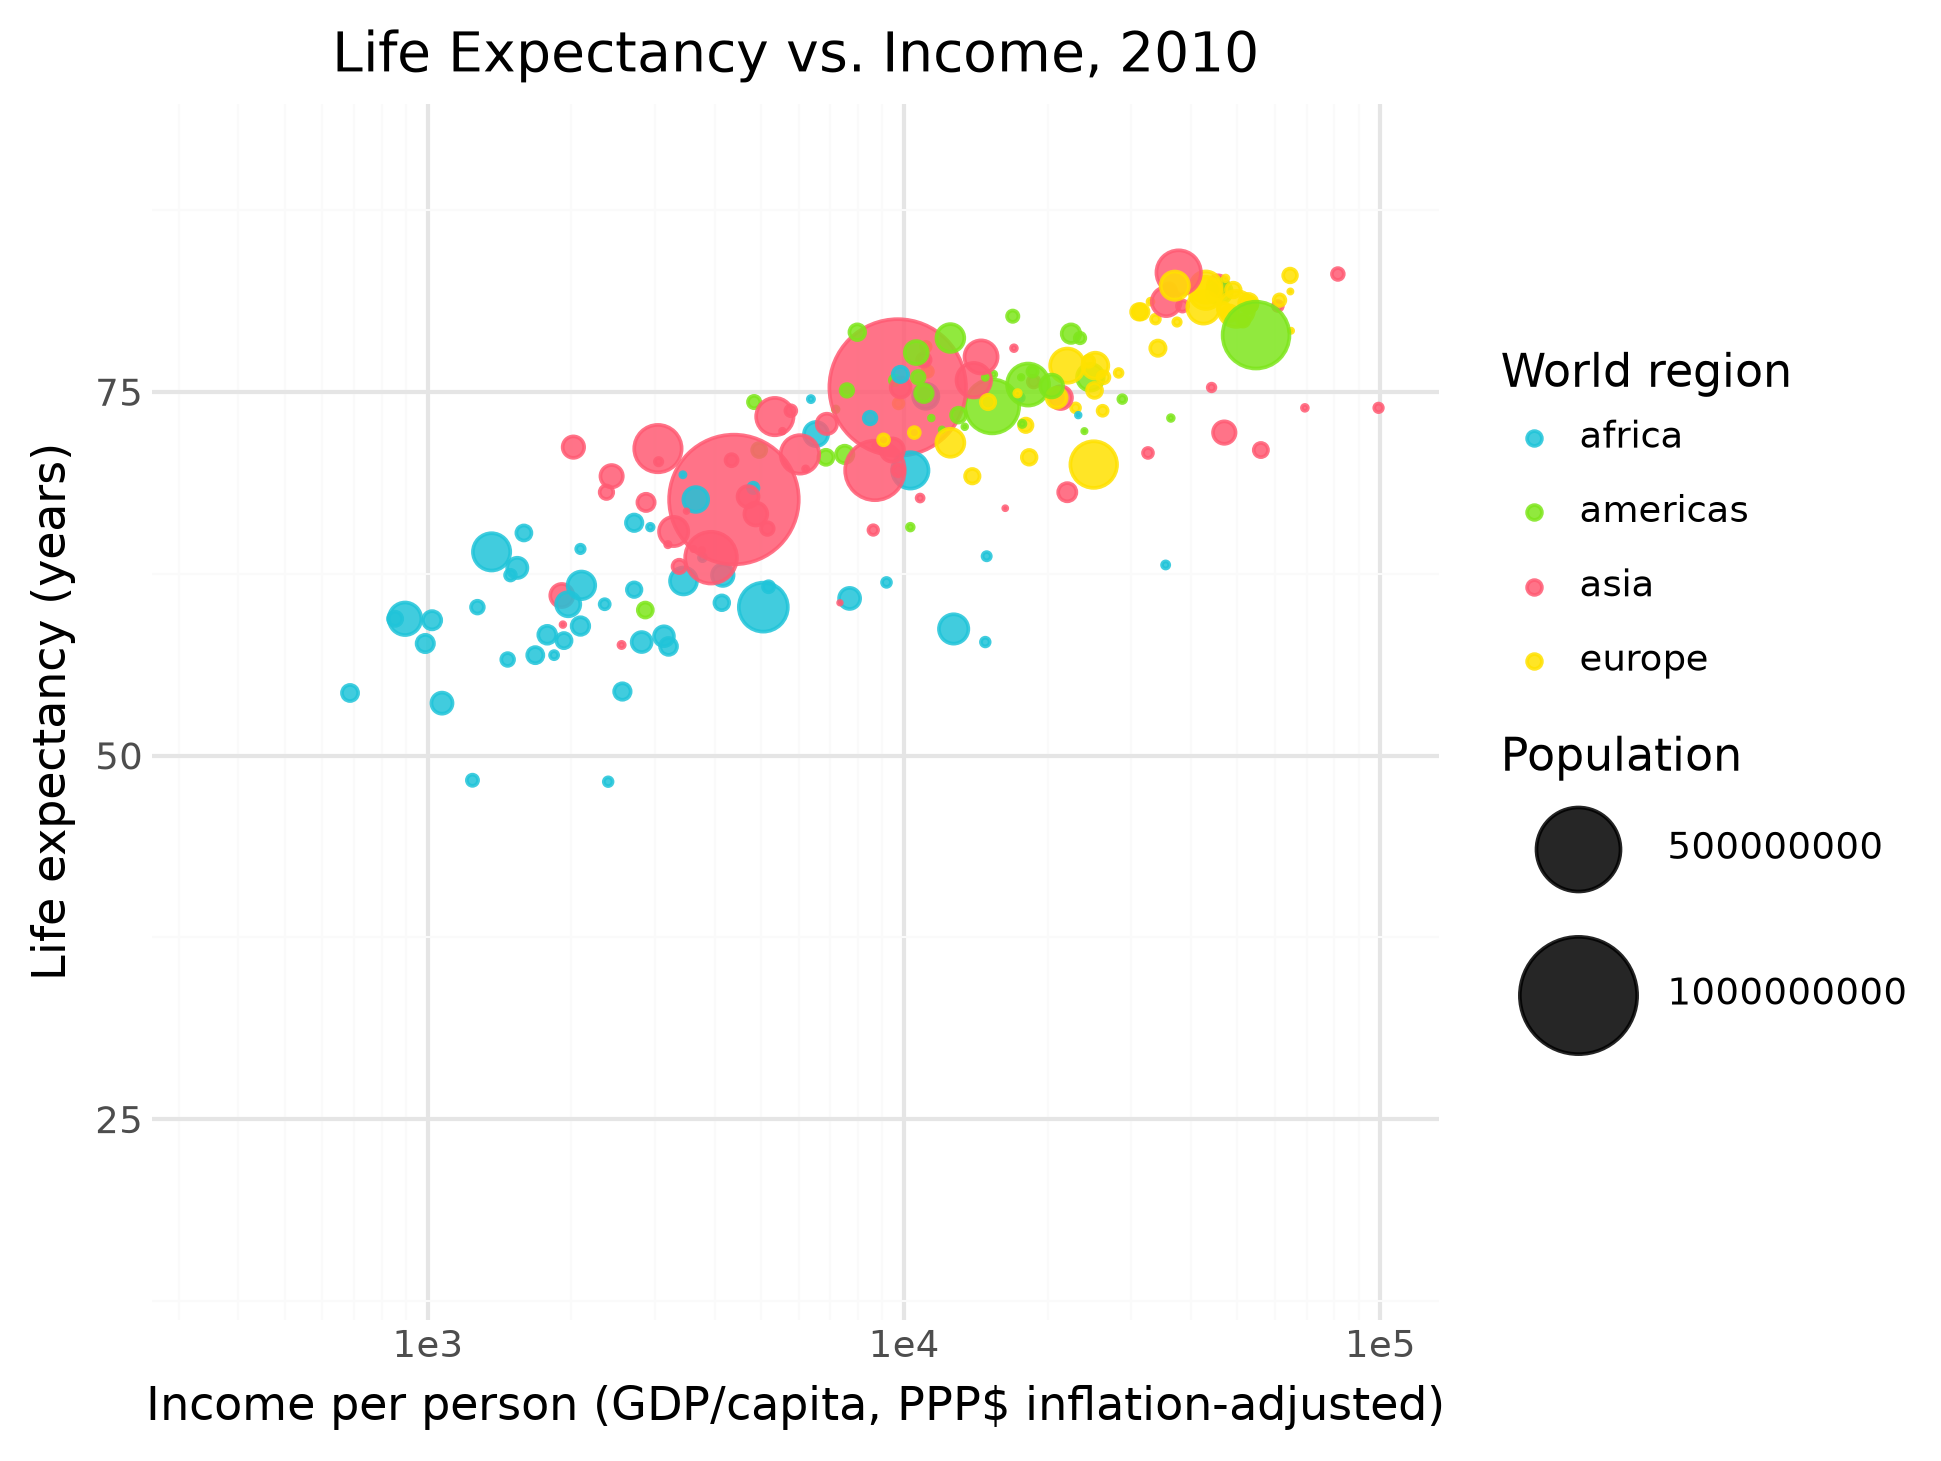

In [10]:
# Plot 1a
from pathlib import Path

import pandas as pd
from plotnine import (
    aes,
    geom_point,
    ggplot,
    labs,
    scale_color_manual,
    scale_size_area,
    scale_x_log10,
    scale_y_continuous,
    theme_minimal,
)

DATA_FILE = Path("Data/q1data.csv")

df = pd.read_csv(DATA_FILE).dropna(
    subset=["income", "life_exp", "population", "four_regions"]
)

region_colors = {
    "africa": "#20c4d9",
    "americas": "#7ee61c",
    "asia": "#ff5b73",
    "europe": "#ffe100",
}

plot1 = (
    ggplot(
        df,
        aes(
            x="income",
            y="life_exp",
            color="four_regions",
            size="population",
        ),
    )
    + geom_point(alpha=0.85)
    + scale_x_log10(limits=(350, 100000))
    + scale_y_continuous(limits=(15, 91))
    + scale_color_manual(values=region_colors)
    + scale_size_area(max_size=18)
    + labs(
        title="Life Expectancy vs. Income, 2010",
        x="Income per person (GDP/capita, PPP$ inflation-adjusted)",
        y="Life expectancy (years)",
        color="World region",
        size="Population",
    )
    + theme_minimal()
)

plot1.save("plot1_bubble_chart.png", width=12, height=7, dpi=300)
plot1.show()

c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 12 x 7 in image.
c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: plot1_text_geometry.png
c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_text : Removed 1 rows containing missing values.
c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_text : Removed 1 rows containing missing values.


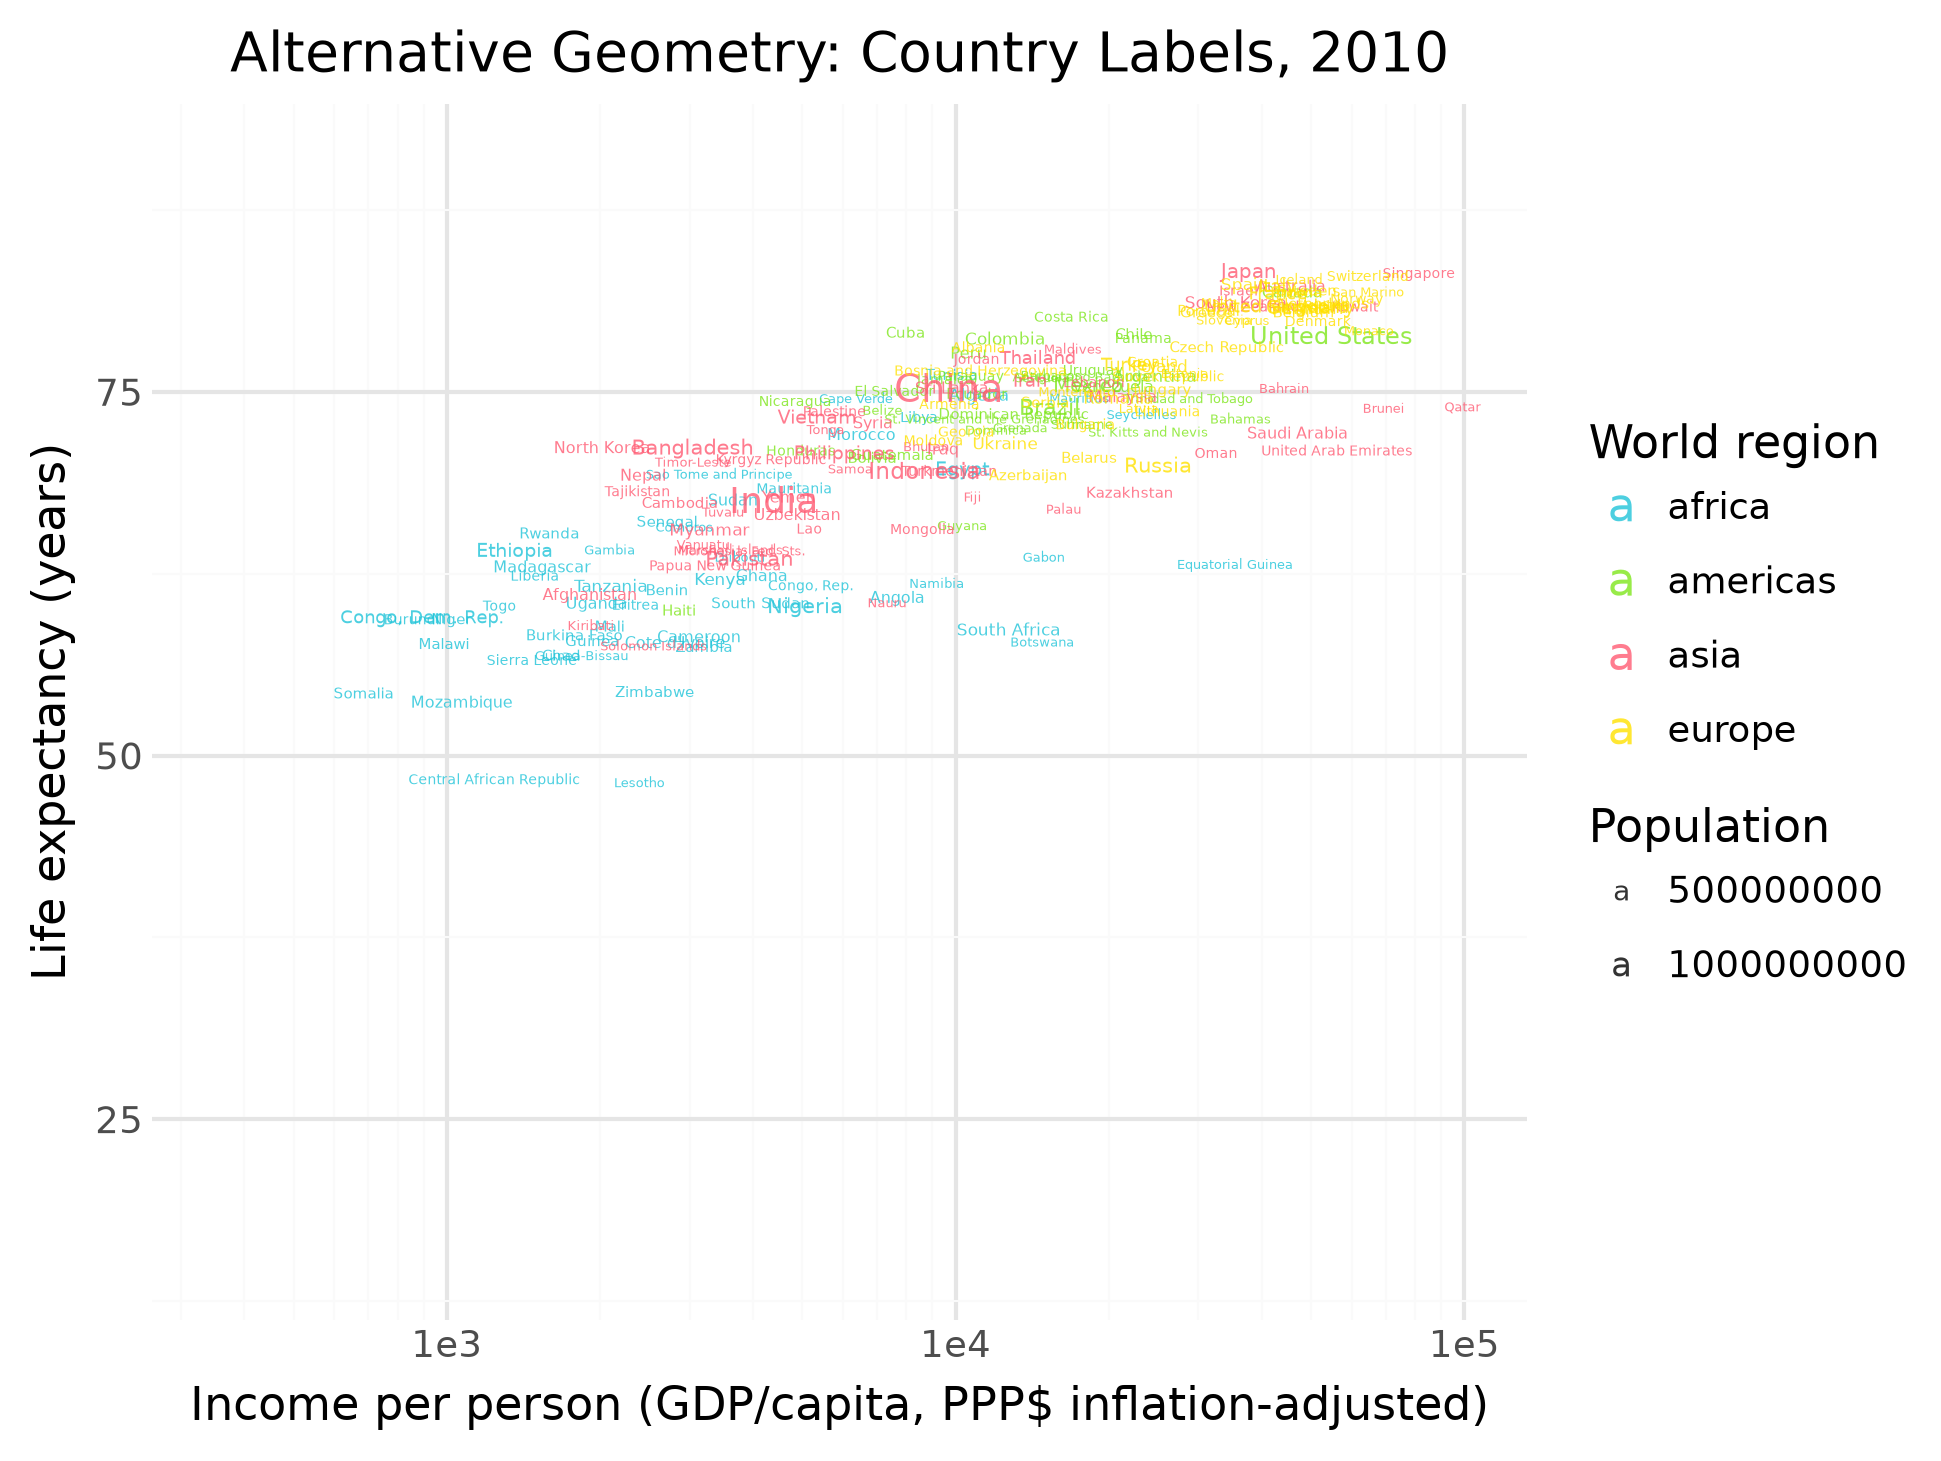

In [11]:
# Plot 1b
from plotnine import geom_text, scale_size_continuous

text_plot = (
    ggplot(
        df,
        aes(
            x="income",
            y="life_exp",
            color="four_regions",
            size="population",
            label="country",
        ),
    )
    + geom_text(alpha=0.8)
    + scale_x_log10(limits=(350, 100000))
    + scale_y_continuous(limits=(15, 91))
    + scale_color_manual(values=region_colors)
    + scale_size_continuous(range=(3, 9))
    + labs(
        title="Alternative Geometry: Country Labels, 2010",
        x="Income per person (GDP/capita, PPP$ inflation-adjusted)",
        y="Life expectancy (years)",
        color="World region",
        size="Population",
    )
    + theme_minimal()
)

text_plot.save("plot1_text_geometry.png", width=12, height=7, dpi=300)
text_plot.show()

# Besides geom_point(), I used geom_text(). The text geometry places each country name at its income and life-expectancy values. The text color represents the country’s world region, and text size represents population. This plot is not very effective because there are many countries, causing labels to overlap and making the plot difficult to read. It is useful for identifying individual countries in a small dataset, but geom_point() is better for this dataset because it displays the overall relationship between income, life expectancy, population, and region more clearly.

c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 12 x 7 in image.
c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: plot2_bubble_chart.png


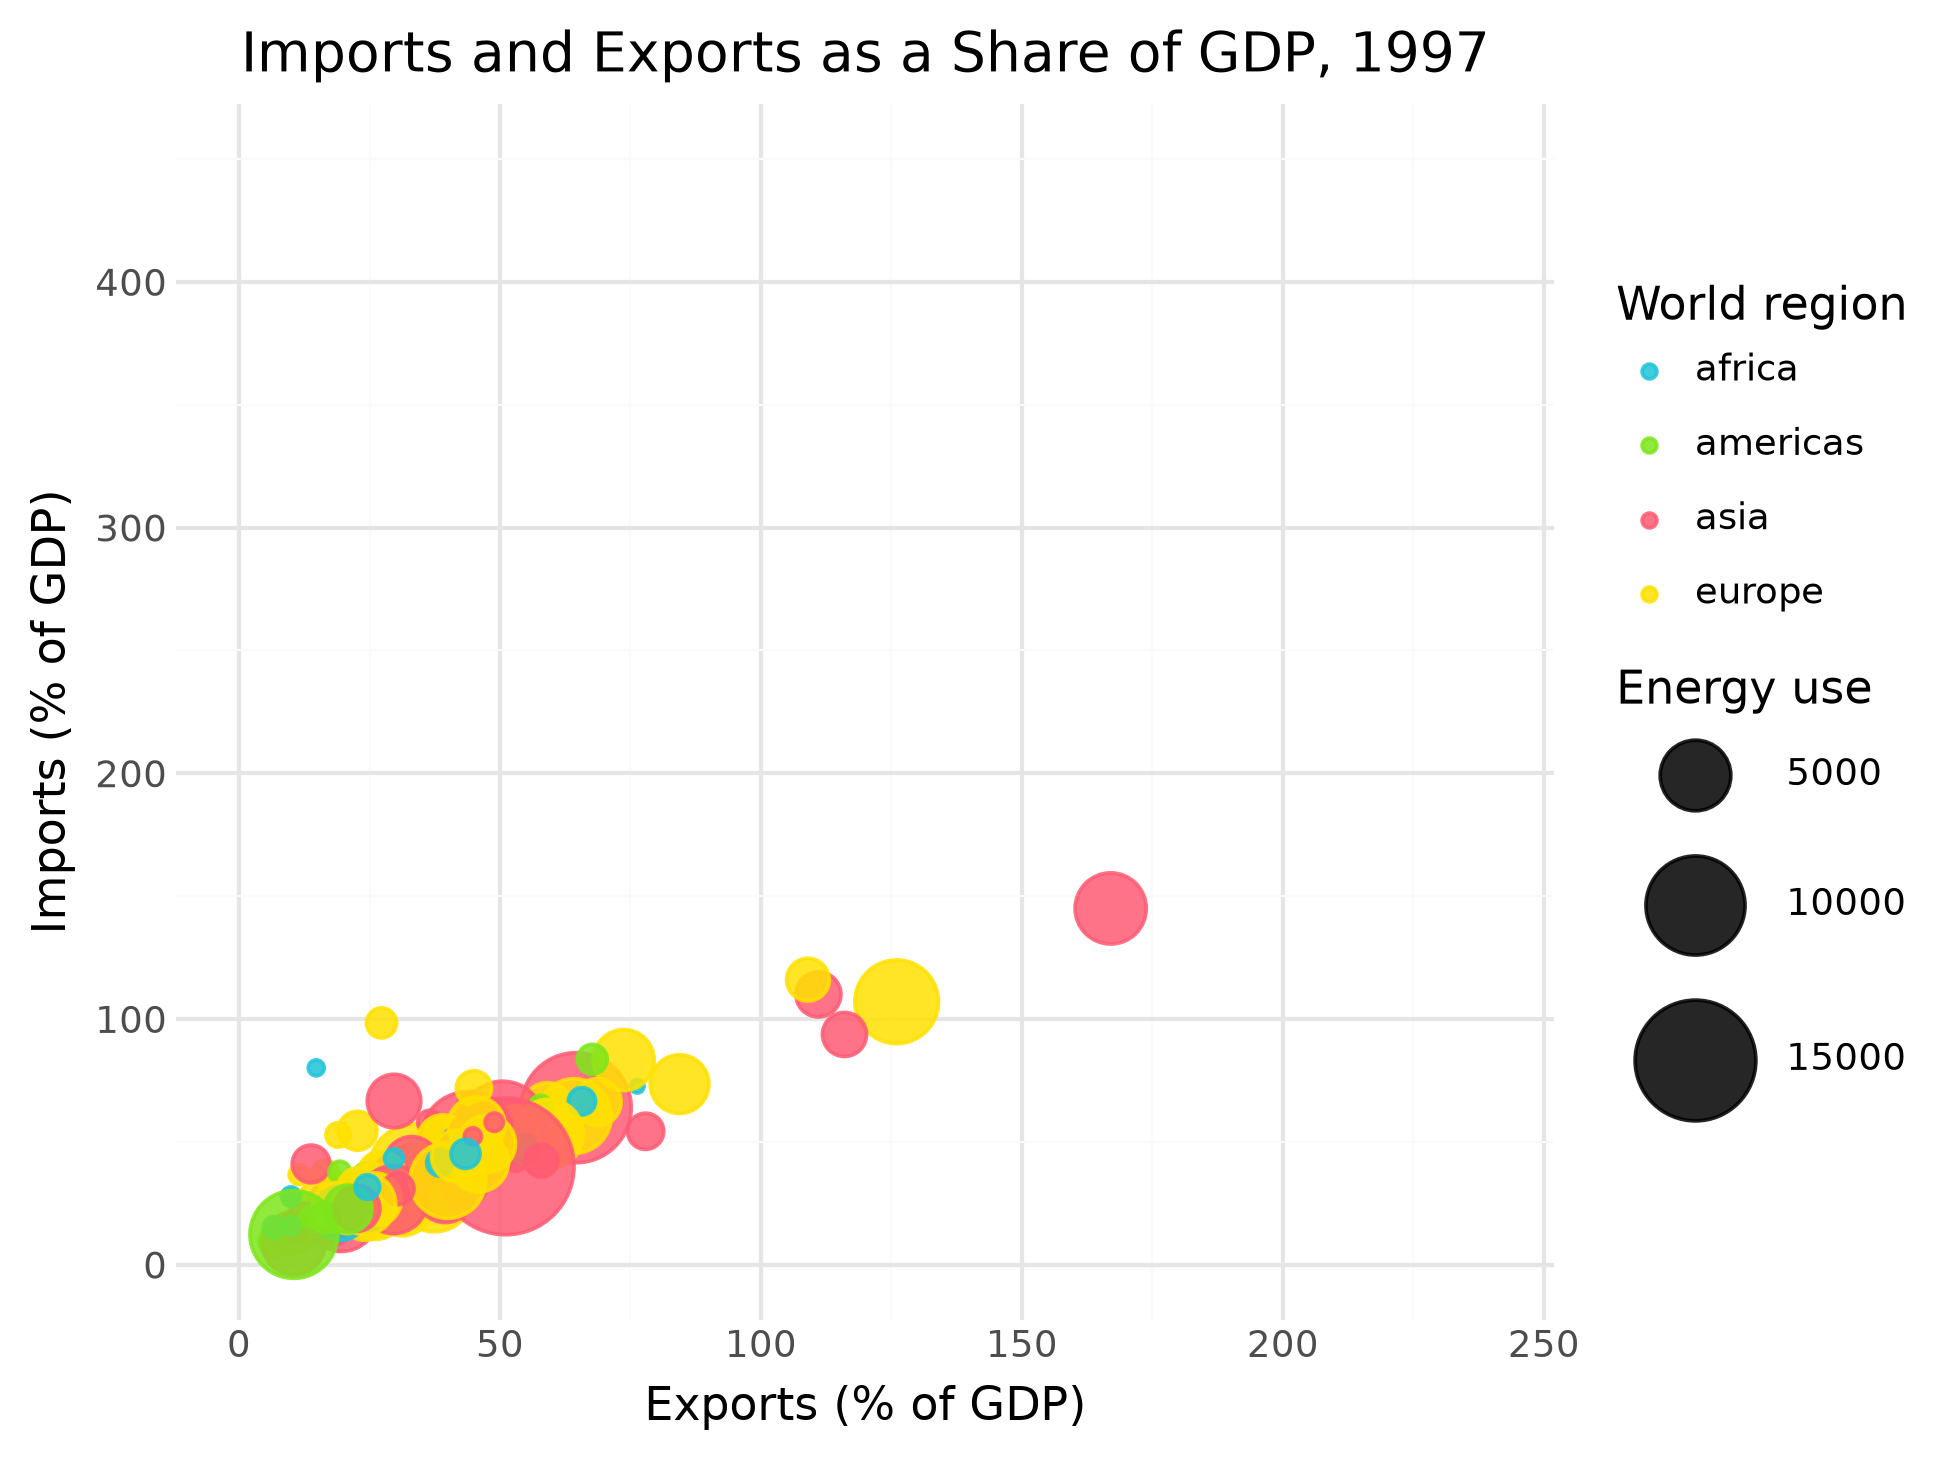

In [12]:
# Plot2a
from pathlib import Path

import pandas as pd
from plotnine import (
    aes,
    geom_point,
    geom_text,
    ggplot,
    labs,
    scale_color_manual,
    scale_size_area,
    scale_size_continuous,
    scale_x_continuous,
    scale_y_continuous,
    theme_minimal,
)

DATA_FILE = Path("Data/q2data.csv")

def clean_energy(value):
    if pd.isna(value):
        return None
    value = str(value)
    return float(value[:-1]) * 1_000 if value.endswith("k") else float(value)


df = pd.read_csv(DATA_FILE)
df["energy_numeric"] = df["energy"].apply(clean_energy)
df = df.dropna(subset=["exports", "imports", "energy_numeric", "four_regions"])

region_colors = {
    "africa": "#20c4d9",
    "americas": "#7ee61c",
    "asia": "#ff5b73",
    "europe": "#ffe100",
}

plot2 = (
    ggplot(
        df,
        aes(x="exports", y="imports", color="four_regions", size="energy_numeric"),
    )
    + geom_point(alpha=0.85)
    + scale_x_continuous(limits=(0, 240))
    + scale_y_continuous(limits=(0, 450))
    + scale_color_manual(values=region_colors)
    + scale_size_area(max_size=18)
    + labs(
        title="Imports and Exports as a Share of GDP, 1997",
        x="Exports (% of GDP)",
        y="Imports (% of GDP)",
        color="World region",
        size="Energy use",
    )
    + theme_minimal()
)

plot2.save("plot2_bubble_chart.png", width=12, height=7, dpi=300)
plot2.show()

c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 12 x 7 in image.
c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: plot2_text_geometry.png


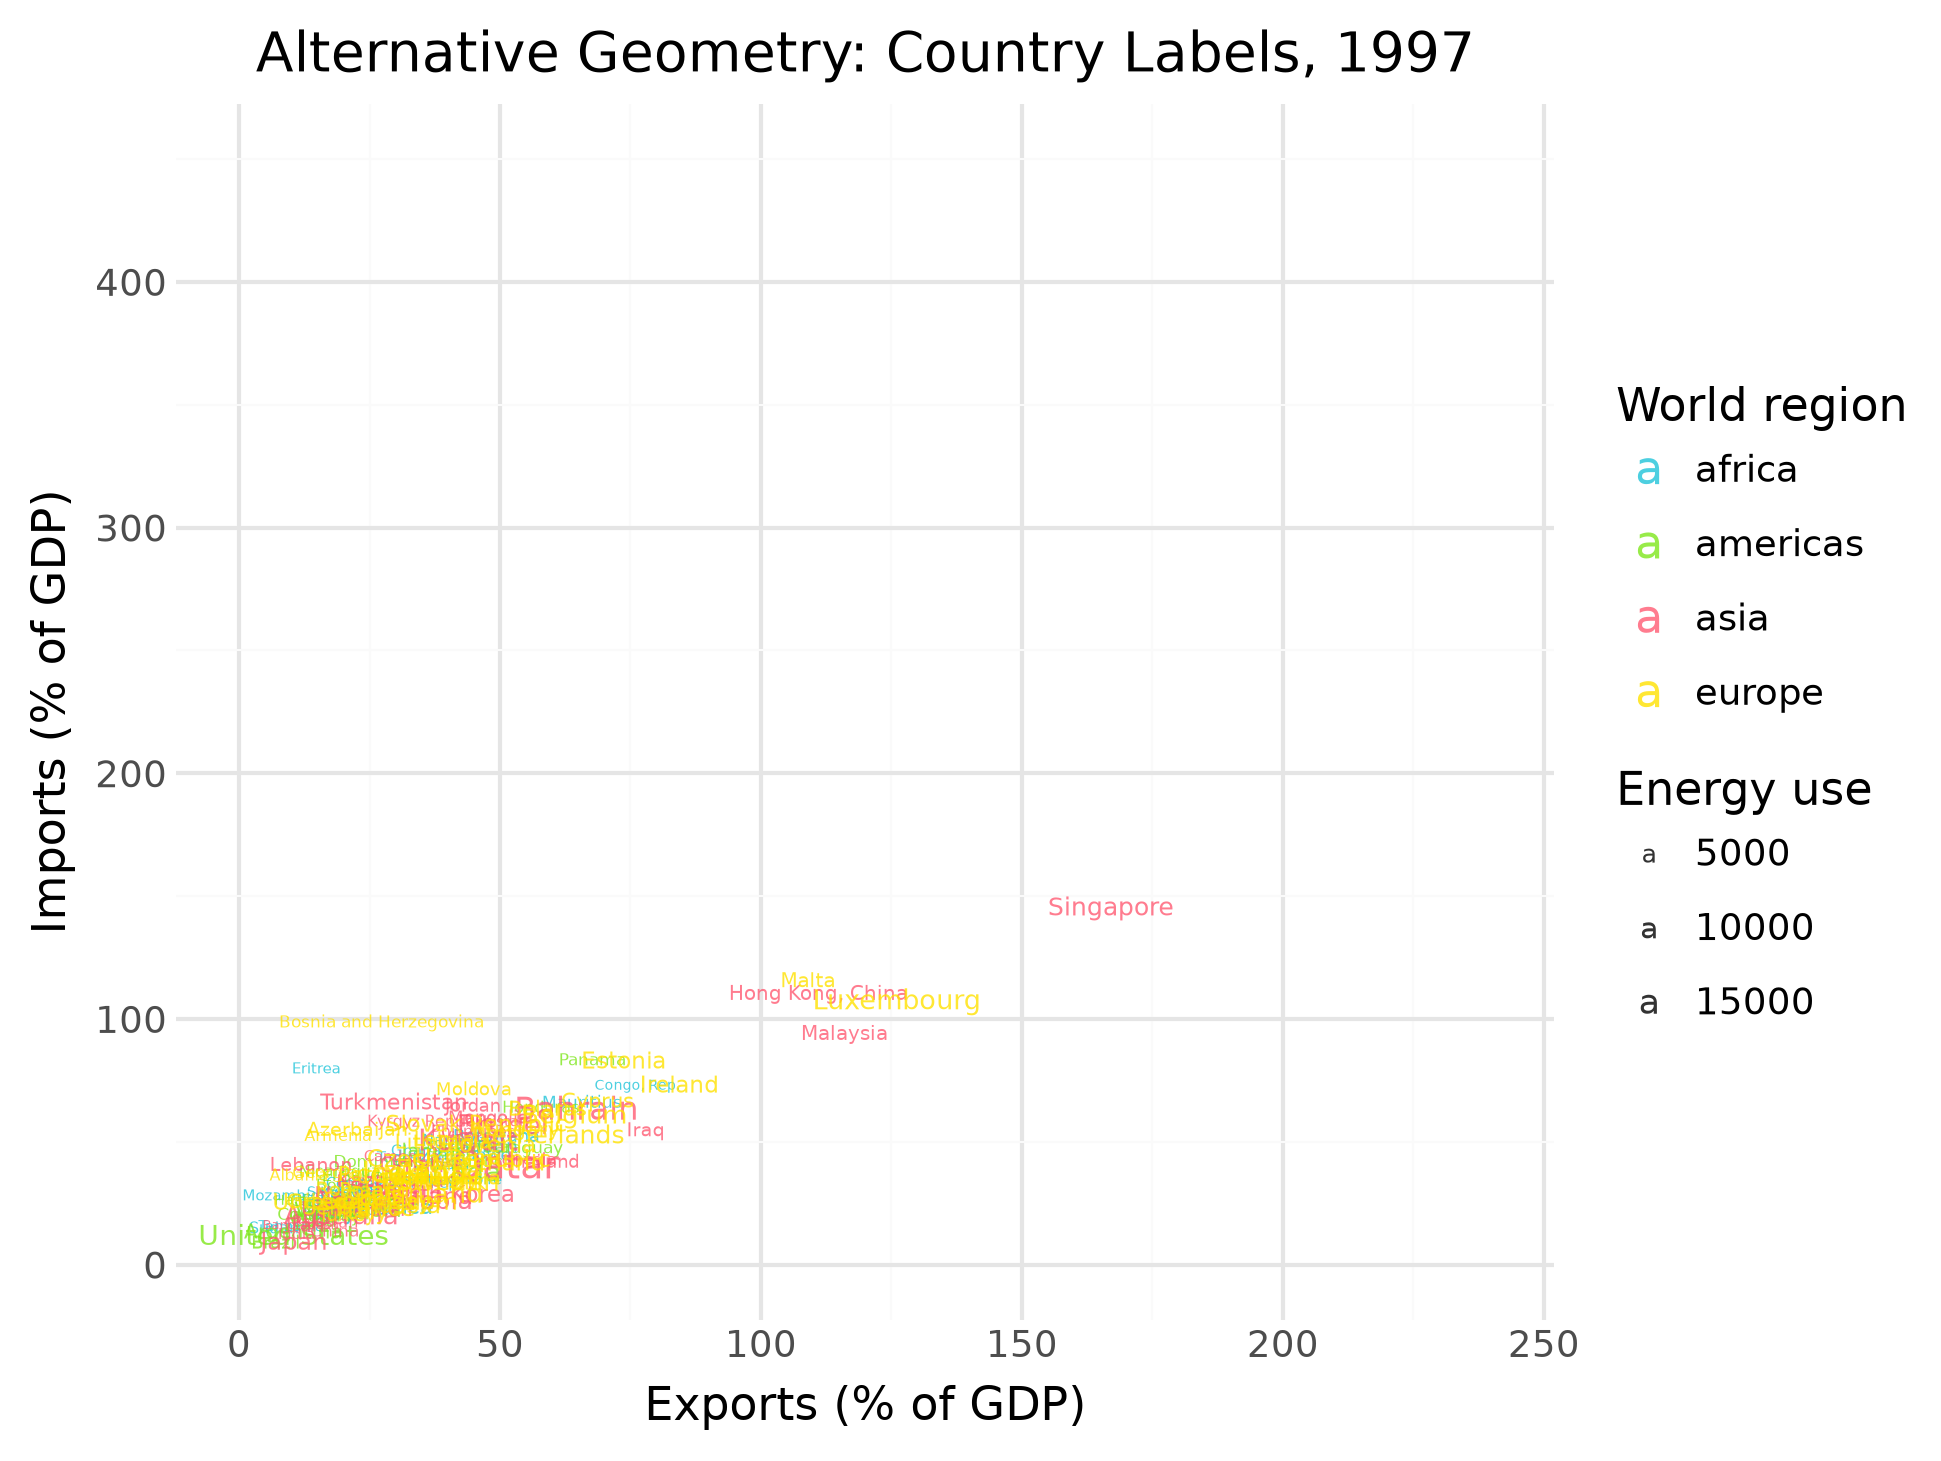

In [13]:
# Plot2b
text_plot2 = (
    ggplot(
        df,
        aes(
            x="exports",
            y="imports",
            color="four_regions",
            size="energy_numeric",
            label="country",
        ),
    )
    + geom_text(alpha=0.8)
    + scale_x_continuous(limits=(0, 240))
    + scale_y_continuous(limits=(0, 450))
    + scale_color_manual(values=region_colors)
    + scale_size_continuous(range=(3, 9))
    + labs(
        title="Alternative Geometry: Country Labels, 1997",
        x="Exports (% of GDP)",
        y="Imports (% of GDP)",
        color="World region",
        size="Energy use",
    )
    + theme_minimal()
)

text_plot2.save("plot2_text_geometry.png", width=12, height=7, dpi=300)
text_plot2.show()

# Besides geom_point(), I used geom_text(). This geometry places each country name at its exports and imports values. Text color represents the country’s world region, and text size represents energy use. This geometry is not very effective for this dataset because many countries have similar imports and exports values. The labels overlap, making the plot crowded and difficult to read. It can be useful for identifying individual countries in a small dataset, but `geom_point()` is better here because it makes the overall relationship between imports, exports, energy use, and world region much easier to see.


c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 12 x 7 in image.
c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: plot3_bubble_chart.png


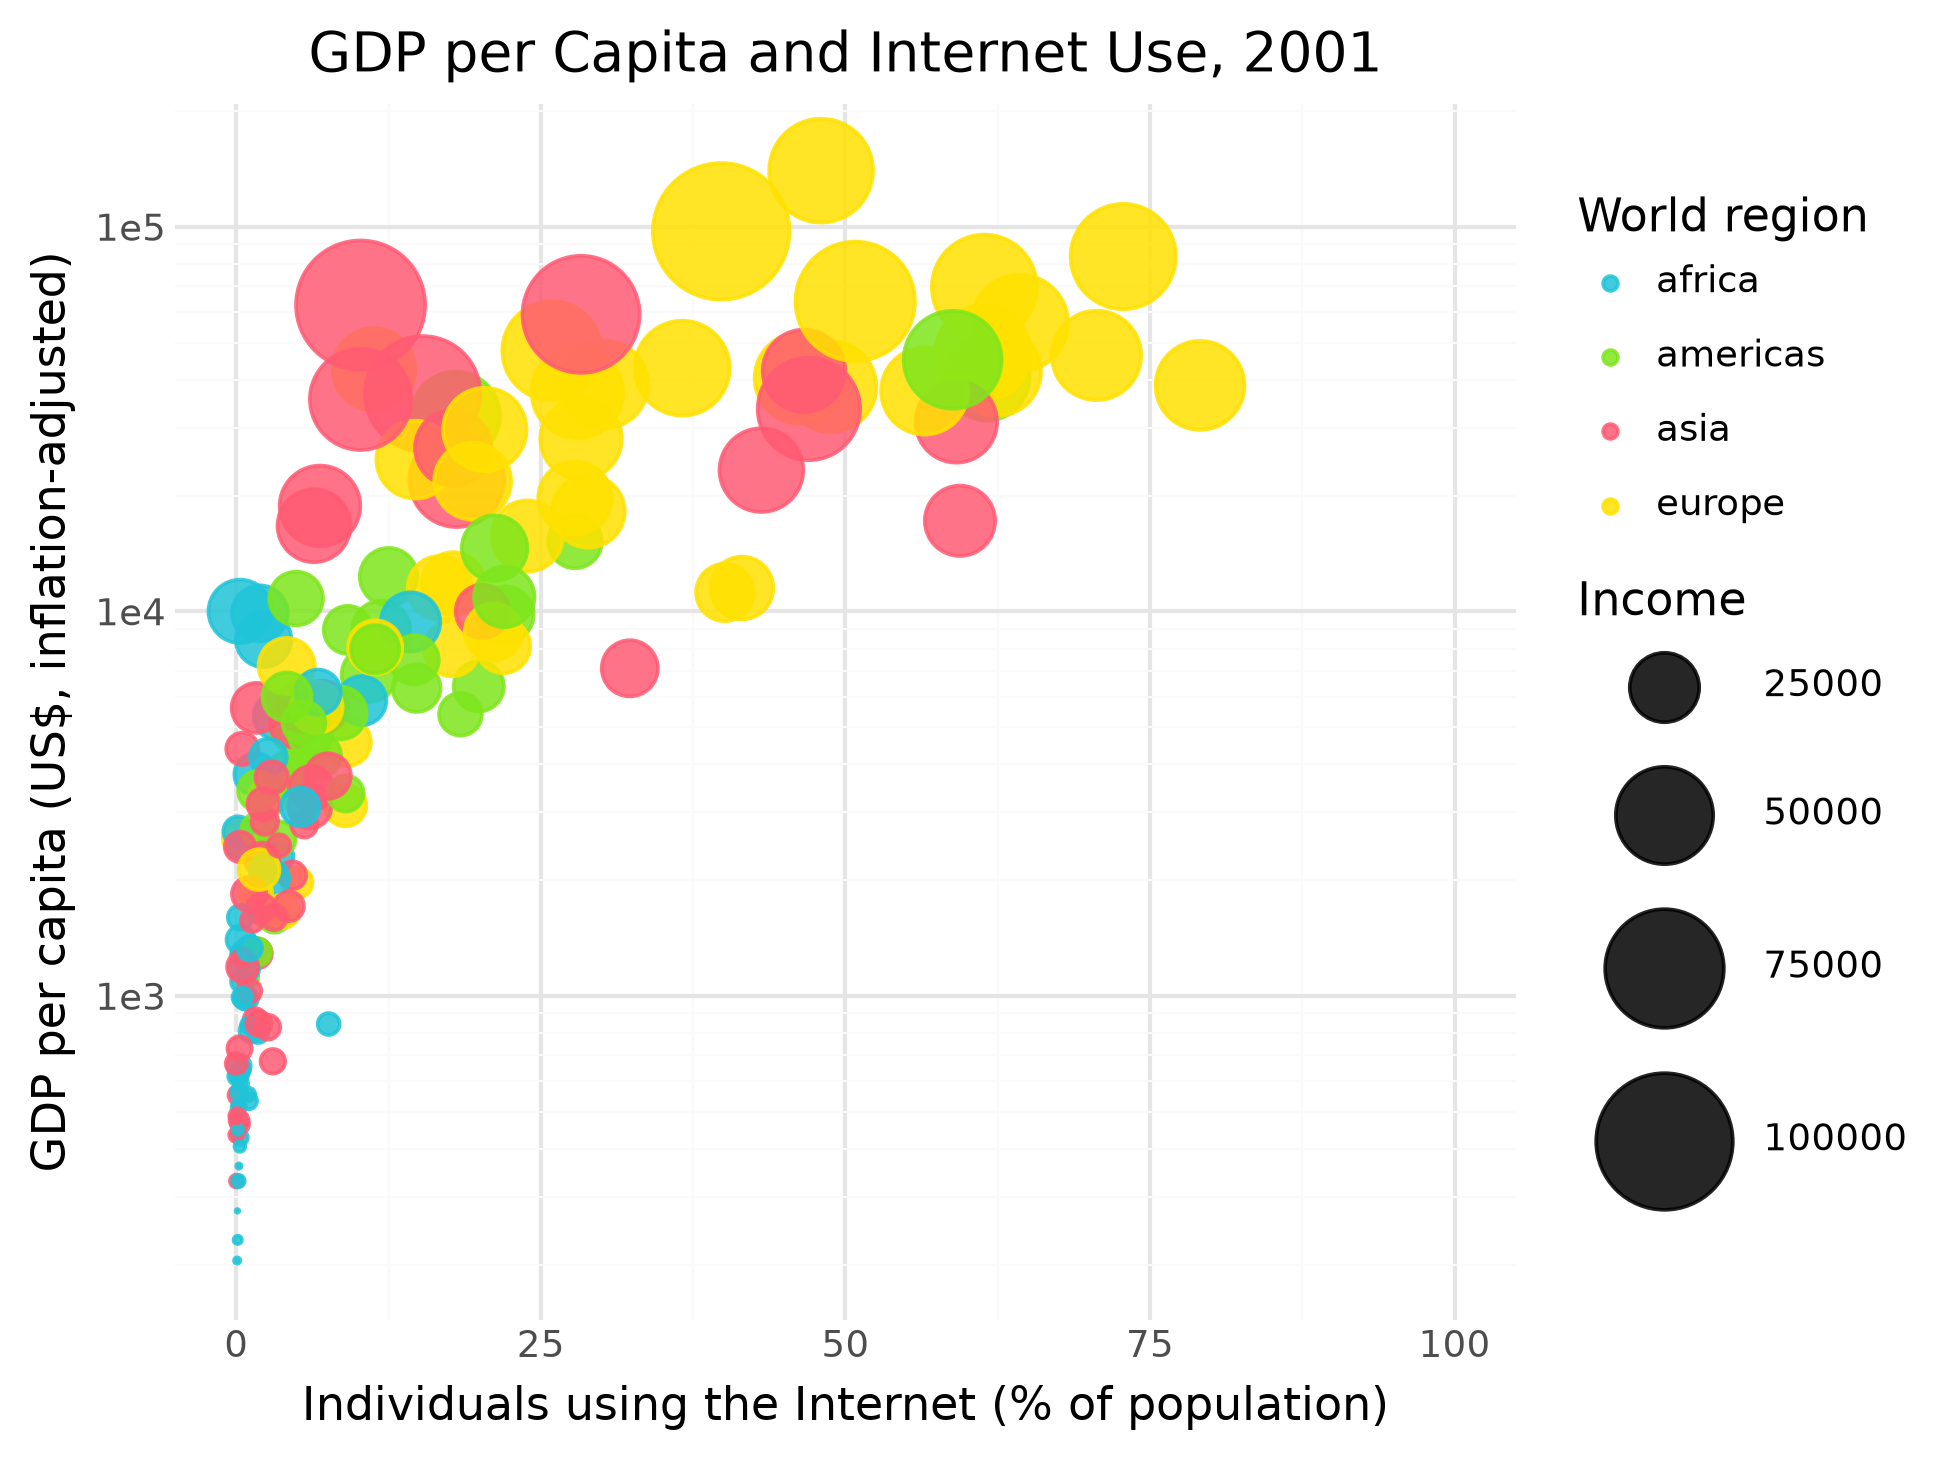

In [14]:
# Plot3a
from pathlib import Path

import pandas as pd
from plotnine import (
    aes,
    geom_point,
    geom_text,
    ggplot,
    labs,
    scale_color_manual,
    scale_size_area,
    scale_size_continuous,
    scale_x_continuous,
    scale_y_log10,
    theme_minimal,
)

DATA_FILE = Path("Data/q3data.csv")

df = pd.read_csv(DATA_FILE).dropna(
    subset=["internet_users", "gdp", "income", "four_regions"]
)

region_colors = {
    "africa": "#20c4d9",
    "americas": "#7ee61c",
    "asia": "#ff5b73",
    "europe": "#ffe100",
}

plot3 = (
    ggplot(
        df,
        aes(x="internet_users", y="gdp", color="four_regions", size="income"),
    )
    + geom_point(alpha=0.85)
    + scale_x_continuous(limits=(0, 100))
    + scale_y_log10(limits=(200, 150_000))
    + scale_color_manual(values=region_colors)
    + scale_size_area(max_size=18)
    + labs(
        title="GDP per Capita and Internet Use, 2001",
        x="Individuals using the Internet (% of population)",
        y="GDP per capita (US$, inflation-adjusted)",
        color="World region",
        size="Income",
    )
    + theme_minimal()
)

plot3.save("plot3_bubble_chart.png", width=12, height=7, dpi=300)
plot3.show()

c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 12 x 7 in image.
c:\Users\aaron\OneDrive\Documents\Masters\Semester1\GSB5544\.conda\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: plot3_text_geometry.png


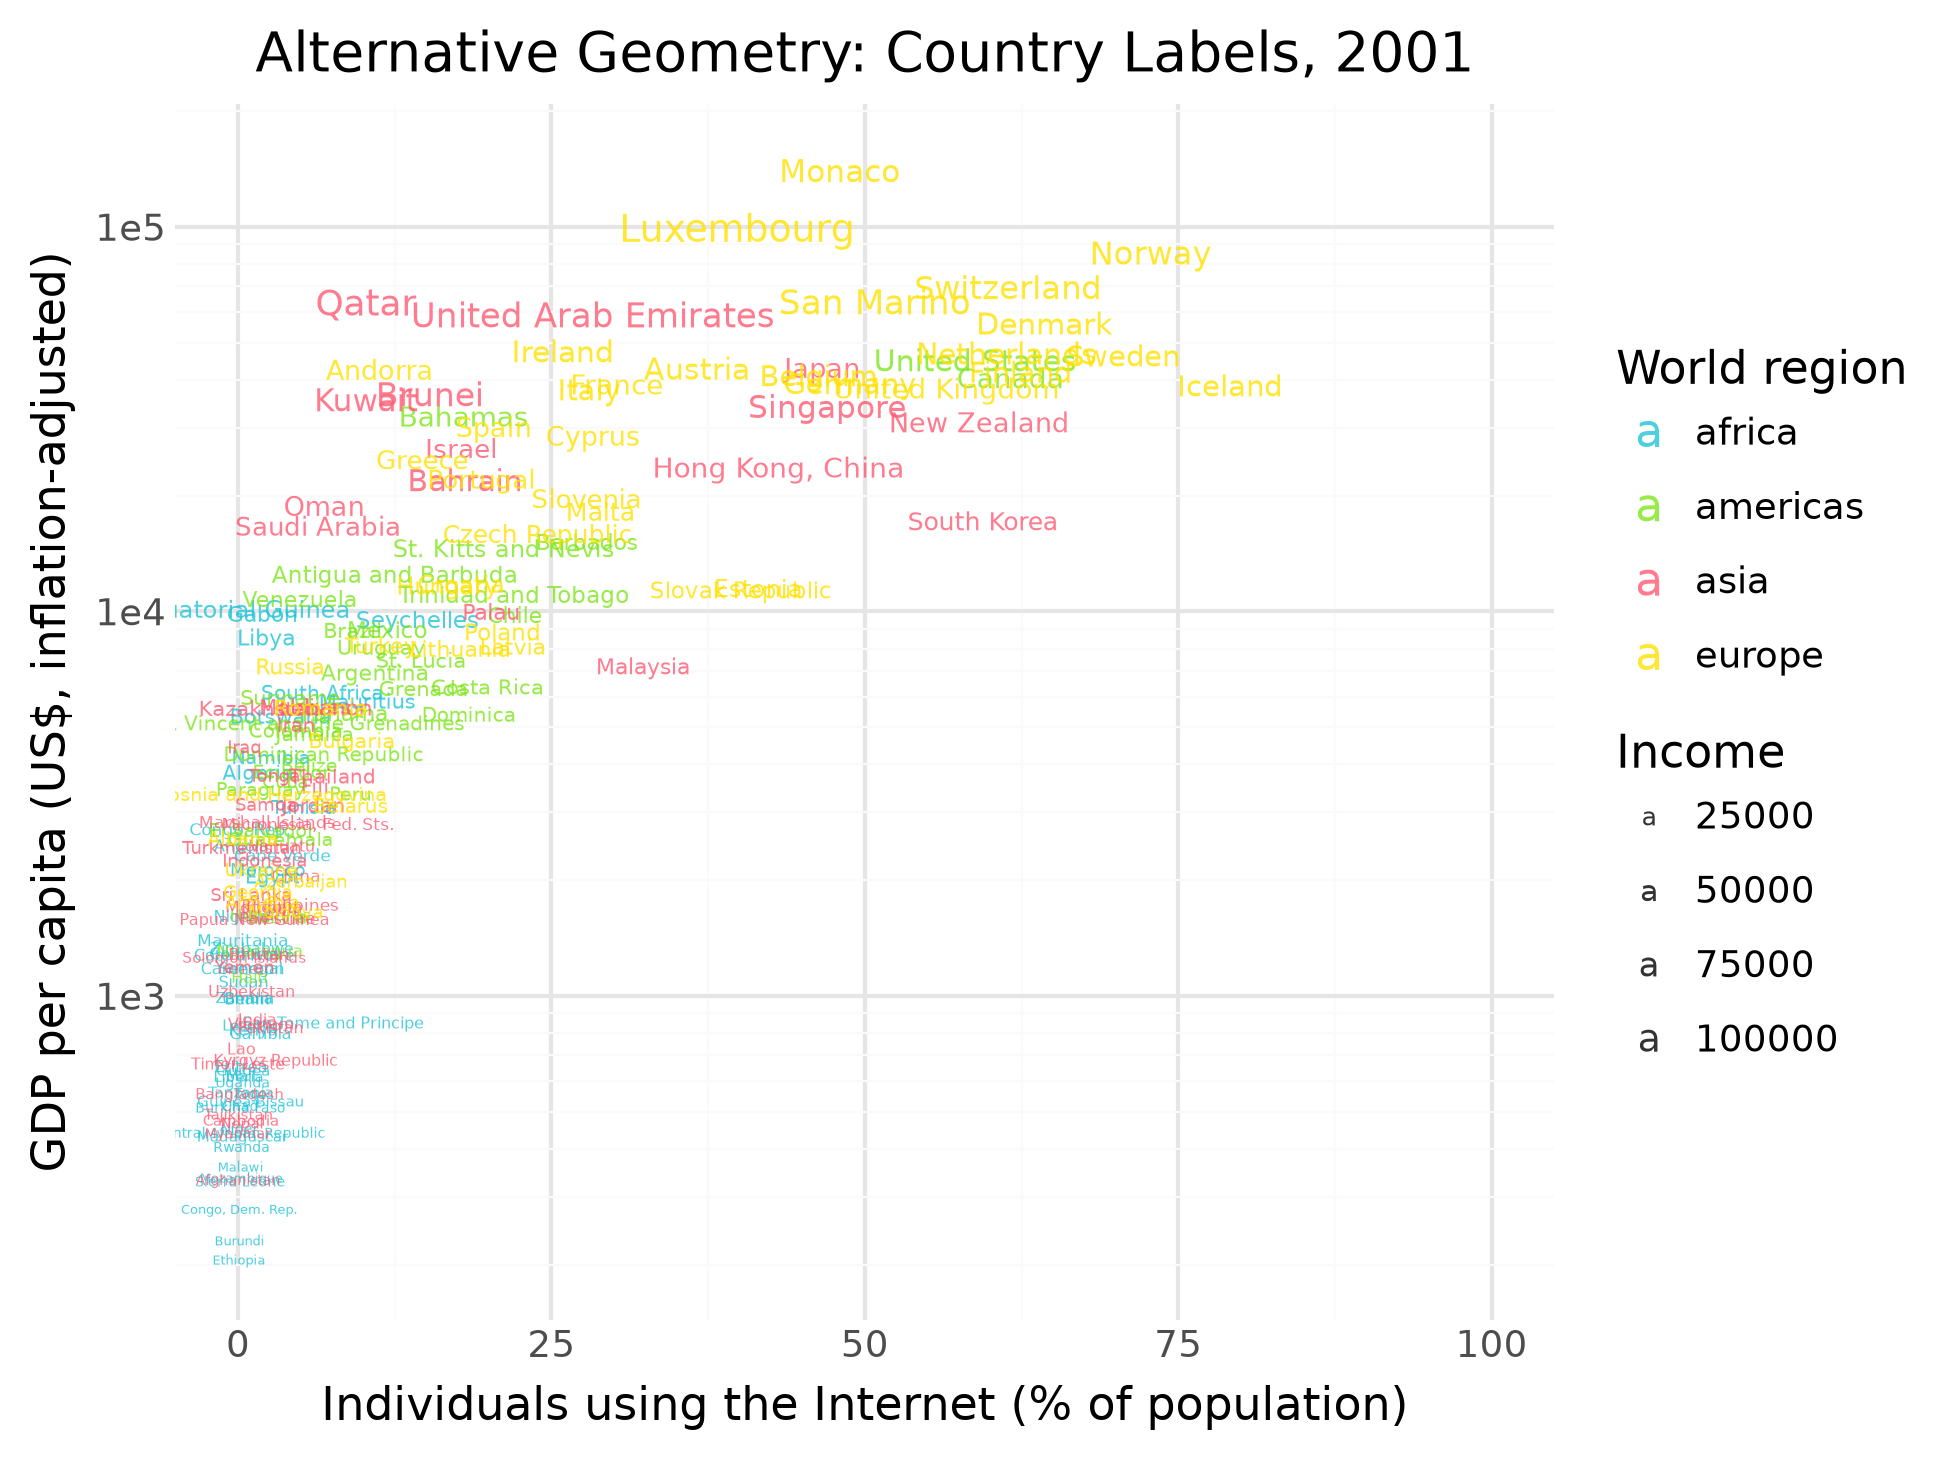

In [15]:
# Plot3b
text_plot3 = (
    ggplot(
        df,
        aes(
            x="internet_users",
            y="gdp",
            color="four_regions",
            size="income",
            label="country",
        ),
    )
    + geom_text(alpha=0.8)
    + scale_x_continuous(limits=(0, 100))
    + scale_y_log10(limits=(200, 150_000))
    + scale_color_manual(values=region_colors)
    + scale_size_continuous(range=(3, 9))
    + labs(
        title="Alternative Geometry: Country Labels, 2001",
        x="Individuals using the Internet (% of population)",
        y="GDP per capita (US$, inflation-adjusted)",
        color="World region",
        size="Income",
    )
    + theme_minimal()
)

text_plot3.save("plot3_text_geometry.png", width=12, height=7, dpi=300)
text_plot3.show()

# Besides geom_point(), I used geom_text(). The text geometry places each country name at its internet-use percentage and GDP-per-capita value. Text color represents the country’s world region, and text size represents income. This geometry is not very effective because many countries are clustered at low internet-use levels. Their labels overlap, making the graph crowded and difficult to read. It could be useful for identifying a few individual countries, but `geom_point()` is better for this dataset because it makes the overall relationship between internet use, GDP per capita, income, and region easier to see.

